# NSCLC Spatial Mean-Split Survival Analysis

This notebook follows the Figure 6 setup from `manuscript-figures.ipynb`: flatten ROI-level non-tumor spatial interaction matrices, merge clinical survival data, aggregate ROI-level interaction features to patient level, then test survival associations.

Only the `mean_cutoff` strategy is kept here. For every directional interaction feature, the mean is computed among available patients, then patients are assigned to low `< mean` and high `>= mean` groups.

The mean-split groups are used only to screen candidate interaction variables with KM/log-rank analysis. The adjusted Cox model uses the raw continuous spatial interaction index for the selected feature, not the mean-split group assignment.

No figures or result tables are saved by this notebook. All outputs are displayed in-memory only.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.exceptions import ConvergenceError

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and cwd.parent.name == "multiTAP":
    PROJECT_ROOT = cwd.parents[1]
elif (cwd / "multiTAP" / "notebooks").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = Path("/project/Xie_Lab/zgu/xiao_multiplex")

WORK_DIR = PROJECT_ROOT / "nsclc_multiTAP_work"
ACCUMUL_TYPE = "sum"
K_NEIGHBORS = 15
SPATIAL_PATH = WORK_DIR / f"nontumor_spatial_kneighbor{K_NEIGHBORS}_{ACCUMUL_TYPE}.csv"
CLINICAL_PATH = WORK_DIR / "clinical_data_ROI.csv"

FDR_ALPHA = 0.05
MINIMUM_PT_THRESH_FRAC = 0.10
MINIMUM_GROUP_SIZE_FRAC_OF_PT_THRESH = 0.30
MINIMUM_GROUP_EVENTS_FRAC_OF_GROUP_SIZE = 0.30

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SPATIAL_PATH = {SPATIAL_PATH}")
print(f"CLINICAL_PATH = {CLINICAL_PATH}")

PROJECT_ROOT = /project/Xie_Lab/zgu/xiao_multiplex
SPATIAL_PATH = /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nontumor_spatial_kneighbor15_sum.csv
CLINICAL_PATH = /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/clinical_data_ROI.csv


## Figure 6 Setup Helpers

In [2]:
def flatten_interaction_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Flatten a square directional spatial interaction matrix into one wide row."""
    if df.shape[0] != df.shape[1]:
        raise ValueError("Input DataFrame must be square.")
    if not df.columns.equals(df.index):
        raise ValueError("DataFrame must have matching row and column labels.")
    colnames = [f"{row}_to_{col}" for row in df.index for col in df.columns]
    return pd.DataFrame([df.to_numpy().flatten()], columns=colnames)


def extract_roi_id(roi_id):
    try:
        split = roi_id.split("_")
        if roi_id.startswith("178_A") or roi_id.startswith("178_C"):
            return f"{split[0]}_{split[2]}{split[3]},{split[4]}"
        if roi_id.startswith("178_B"):
            return f"{split[0]}_{split[3]}{split[4]},{split[5]}"
        return f"{split[0]}_{split[2]},{split[3]}"
    except IndexError:
        return None


cell_type_cols = [
    "final_cell_type_B cells", "final_cell_type_CD4", "final_cell_type_CD4 Treg",
    "final_cell_type_CD8", "final_cell_type_Collagen CAF", "final_cell_type_IDO_CD4",
    "final_cell_type_IDO_CD8", "final_cell_type_IFN CAF", "final_cell_type_Ki67_CD4",
    "final_cell_type_Ki67_CD8", "final_cell_type_PD1 CD4", "final_cell_type_PDPN CAF",
    "final_cell_type_SMA CAF", "final_cell_type_TCF1/7 CD4", "final_cell_type_TCF1/7 CD8",
    "final_cell_type_dCAF", "final_cell_type_endothelial",
    "final_cell_type_high endothelial venules (HEV)", "final_cell_type_hypoxic CAF",
    "final_cell_type_hypoxic tCAF", "final_cell_type_iCAF", "final_cell_type_lymphatic endothelial",
    "final_cell_type_mCAF", "final_cell_type_myeloid", "final_cell_type_neutrophils",
    "final_cell_type_tCAF", "final_cell_type_vCAF",
]

## Load And Flatten ROI-Level Spatial Interactions

In [3]:
spatial_pt_df = pd.read_csv(SPATIAL_PATH, index_col=0)
print(f"{spatial_pt_df['roi_id'].nunique()} ROIs identified before flattening")

spatial_pt_df = spatial_pt_df.reset_index(names="cell_type")
spatial_pt_df = spatial_pt_df.replace(0, np.nan)

flat_marker_roi_list = []
for roi_id in np.unique(spatial_pt_df["roi_id"]):
    try:
        one_spatial_mat = spatial_pt_df.loc[spatial_pt_df["roi_id"] == roi_id].copy()
        one_spatial_mat = one_spatial_mat.set_index("cell_type").drop(columns="roi_id")
        flat_roi = flatten_interaction_matrix(one_spatial_mat)
        flat_roi["ROI_ID"] = roi_id
        flat_marker_roi_list.append(flat_roi)
    except Exception as exc:
        print(f"ROI {roi_id} not processed due to error: {exc}")

combined_df = pd.concat(flat_marker_roi_list, axis=0, ignore_index=True)
combined_df["roi_mappable"] = combined_df["ROI_ID"].str.replace("NSCLC_ALL_", "", regex=False).apply(extract_roi_id)
print("flattened ROI-feature table:", combined_df.shape)
display(combined_df.head())

1950 ROIs identified before flattening
flattened ROI-feature table: (1950, 731)


,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,final_cell_type_B cells_to_final_cell_type_Ki67_CD8,final_cell_type_B cells_to_final_cell_type_PD1 CD4,final_cell_type_B cells_to_final_cell_type_PDPN CAF,final_cell_type_B cells_to_final_cell_type_SMA CAF,final_cell_type_B cells_to_final_cell_type_TCF1/7 CD4,final_cell_type_B cells_to_final_cell_type_TCF1/7 CD8,final_cell_type_B cells_to_final_cell_type_dCAF,final_cell_type_B cells_to_final_cell_type_endothelial,final_cell_type_B cells_to_final_cell_type_high endothelial venules (HEV),final_cell_type_B cells_to_final_cell_type_hypoxic CAF,final_cell_type_B cells_to_final_cell_type_hypoxic tCAF,final_cell_type_B cells_to_final_cell_type_iCAF,final_cell_type_B cells_to_final_cell_type_lymphatic endothelial,final_cell_type_B cells_to_final_cell_type_mCAF,final_cell_type_B cells_to_final_cell_type_myeloid,final_cell_type_B cells_to_final_cell_type_neutrophils,final_cell_type_B cells_to_final_cell_type_tCAF,final_cell_type_B cells_to_final_cell_type_vCAF,final_cell_type_CD4_to_final_cell_type_B cells,final_cell_type_CD4_to_final_cell_type_CD4,final_cell_type_CD4_to_final_cell_type_CD4 Treg,final_cell_type_CD4_to_final_cell_type_CD8,final_cell_type_CD4_to_final_cell_type_Collagen CAF,final_cell_type_CD4_to_final_cell_type_IDO_CD4,final_cell_type_CD4_to_final_cell_type_IDO_CD8,final_cell_type_CD4_to_final_cell_type_IFN CAF,final_cell_type_CD4_to_final_cell_type_Ki67_CD4,final_cell_type_CD4_to_final_cell_type_Ki67_CD8,final_cell_type_CD4_to_final_cell_type_PD1 CD4,final_cell_type_CD4_to_final_cell_type_PDPN CAF,final_cell_type_CD4_to_final_cell_type_SMA CAF,...,final_cell_type_tCAF_to_final_cell_type_endothelial,final_cell_type_tCAF_to_final_cell_type_high endothelial venules (HEV),final_cell_type_tCAF_to_final_cell_type_hypoxic CAF,final_cell_type_tCAF_to_final_cell_type_hypoxic tCAF,final_cell_type_tCAF_to_final_cell_type_iCAF,final_cell_type_tCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_tCAF_to_final_cell_type_mCAF,final_cell_type_tCAF_to_final_cell_type_myeloid,final_cell_type_tCAF_to_final_cell_type_neutrophils,final_cell_type_tCAF_to_final_cell_type_tCAF,final_cell_type_tCAF_to_final_cell_type_vCAF,final_cell_type_vCAF_to_final_cell_type_B cells,final_cell_type_vCAF_to_final_cell_type_CD4,final_cell_type_vCAF_to_final_cell_type_CD4 Treg,final_cell_type_vCAF_to_final_cell_type_CD8,final_cell_type_vCAF_to_final_cell_type_Collagen CAF,final_cell_type_vCAF_to_final_cell_type_IDO_CD4,final_cell_type_vCAF_to_final_cell_type_IDO_CD8,final_cell_type_vCAF_to_final_cell_type_IFN CAF,final_cell_type_vCAF_to_final_cell_type_Ki67_CD4,final_cell_type_vCAF_to_final_cell_type_Ki67_CD8,final_cell_type_vCAF_to_final_cell_type_PD1 CD4,final_cell_type_vCAF_to_final_cell_type_PDPN CAF,final_cell_type_vCAF_to_final_cell_type_SMA CAF,final_cell_type_vCAF_to_final_cell_type_TCF1/7 CD4,final_cell_type_vCAF_to_final_cell_type_TCF1/7 CD8,final_cell_type_vCAF_to_final_cell_type_dCAF,final_cell_type_vCAF_to_final_cell_type_endothelial,final_cell_type_vCAF_to_final_cell_type_high endothelial venules (HEV),final_cell_type_vCAF_to_final_cell_type_hypoxic CAF,final_cell_type_vCAF_to_final_cell_type_hypoxic tCAF,final_cell_type_vCAF_to_final_cell_type_iCAF,final_cell_type_vCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_vCAF_to_final_cell_type_mCAF,final_cell_type_vCAF_to_final_cell_type_myeloid,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,ROI_ID,roi_mappable
0,0.130844,NaN,NaN,NaN,NaN,N

## Merge Clinical Data And Aggregate To Patient Level

In [4]:
pt_clinical_data = pd.read_csv(CLINICAL_PATH)
print(f"{pt_clinical_data['Patient_ID'].nunique()} unique subjects before filtering")

pt_clinical_data = pt_clinical_data.loc[pt_clinical_data["Patient_ID"] != "Control"].copy()
pt_clinical_data = pt_clinical_data.loc[~pt_clinical_data["NeoAdj"].isna()].copy()
pt_clinical_data = pt_clinical_data.loc[pt_clinical_data["NeoAdj"] != "NeoAdjuvantTherapy"].reset_index(drop=True)
print(f"{pt_clinical_data['Patient_ID'].nunique()} unique patients after clinical filtering")

survival_clinical_cols = ["RoiID", "Patient_ID", "OS", "DFS", "Ev.O", "DX.name"]
pt_clinical_survival = pt_clinical_data[survival_clinical_cols].drop_duplicates(keep="first").reset_index(drop=True)

spatial_clinical_merged = combined_df.merge(
    pt_clinical_survival,
    how="inner",
    left_on="roi_mappable",
    right_on="RoiID",
)
spatial_clinical_merged = spatial_clinical_merged.dropna(subset=["OS", "Ev.O"]).reset_index(drop=True)
print("unique patients after ROI/survival merge:", spatial_clinical_merged["Patient_ID"].nunique())
print("unique ROIs after ROI/survival merge:", spatial_clinical_merged["roi_mappable"].nunique())

marker_cols = list(spatial_clinical_merged.columns[spatial_clinical_merged.columns.str.contains("final_cell_type")])
keep_cols = marker_cols + ["OS", "Ev.O", "Patient_ID", "DX.name"]
spatial_clinical_for_survival = spatial_clinical_merged[keep_cols].copy()

tumor_type_conflicts = spatial_clinical_for_survival.groupby("Patient_ID")["DX.name"].nunique(dropna=False)
tumor_type_conflicts = tumor_type_conflicts[tumor_type_conflicts > 1]
print(f"Patients with ROI-level tumor type conflicts: {len(tumor_type_conflicts)}")

spatial_clinical_for_survival = spatial_clinical_for_survival.groupby("Patient_ID").agg(
    {**{col: "mean" for col in marker_cols + ["OS", "Ev.O"]}, "DX.name": "first"}
).reset_index()

minimum_pt_thresh = int(MINIMUM_PT_THRESH_FRAC * len(spatial_clinical_for_survival))
minimum_group_size = int(MINIMUM_GROUP_SIZE_FRAC_OF_PT_THRESH * minimum_pt_thresh)
minimum_group_events = int(MINIMUM_GROUP_EVENTS_FRAC_OF_GROUP_SIZE * minimum_group_size)

print("patient-level survival frame:", spatial_clinical_for_survival.shape)
print(f"minimum_pt_thresh={minimum_pt_thresh}, minimum_group_size={minimum_group_size}, minimum_group_events={minimum_group_events}")
display(spatial_clinical_for_survival.head())

1071 unique subjects before filtering
959 unique patients after clinical filtering
unique patients after ROI/survival merge: 953
unique ROIs after ROI/survival merge: 1755
Patients with ROI-level tumor type conflicts: 0
patient-level survival frame: (953, 733)
minimum_pt_thresh=95, minimum_group_size=28, minimum_group_events=8


,Patient_ID,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,final_cell_type_B cells_to_final_cell_type_Ki67_CD8,final_cell_type_B cells_to_final_cell_type_PD1 CD4,final_cell_type_B cells_to_final_cell_type_PDPN CAF,final_cell_type_B cells_to_final_cell_type_SMA CAF,final_cell_type_B cells_to_final_cell_type_TCF1/7 CD4,final_cell_type_B cells_to_final_cell_type_TCF1/7 CD8,final_cell_type_B cells_to_final_cell_type_dCAF,final_cell_type_B cells_to_final_cell_type_endothelial,final_cell_type_B cells_to_final_cell_type_high endothelial venules (HEV),final_cell_type_B cells_to_final_cell_type_hypoxic CAF,final_cell_type_B cells_to_final_cell_type_hypoxic tCAF,final_cell_type_B cells_to_final_cell_type_iCAF,final_cell_type_B cells_to_final_cell_type_lymphatic endothelial,final_cell_type_B cells_to_final_cell_type_mCAF,final_cell_type_B cells_to_final_cell_type_myeloid,final_cell_type_B cells_to_final_cell_type_neutrophils,final_cell_type_B cells_to_final_cell_type_tCAF,final_cell_type_B cells_to_final_cell_type_vCAF,final_cell_type_CD4_to_final_cell_type_B cells,final_cell_type_CD4_to_final_cell_type_CD4,final_cell_type_CD4_to_final_cell_type_CD4 Treg,final_cell_type_CD4_to_final_cell_type_CD8,final_cell_type_CD4_to_final_cell_type_Collagen CAF,final_cell_type_CD4_to_final_cell_type_IDO_CD4,final_cell_type_CD4_to_final_cell_type_IDO_CD8,final_cell_type_CD4_to_final_cell_type_IFN CAF,final_cell_type_CD4_to_final_cell_type_Ki67_CD4,final_cell_type_CD4_to_final_cell_type_Ki67_CD8,final_cell_type_CD4_to_final_cell_type_PD1 CD4,final_cell_type_CD4_to_final_cell_type_PDPN CAF,...,final_cell_type_tCAF_to_final_cell_type_high endothelial venules (HEV),final_cell_type_tCAF_to_final_cell_type_hypoxic CAF,final_cell_type_tCAF_to_final_cell_type_hypoxic tCAF,final_cell_type_tCAF_to_final_cell_type_iCAF,final_cell_type_tCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_tCAF_to_final_cell_type_mCAF,final_cell_type_tCAF_to_final_cell_type_myeloid,final_cell_type_tCAF_to_final_cell_type_neutrophils,final_cell_type_tCAF_to_final_cell_type_tCAF,final_cell_type_tCAF_to_final_cell_type_vCAF,final_cell_type_vCAF_to_final_cell_type_B cells,final_cell_type_vCAF_to_final_cell_type_CD4,final_cell_type_vCAF_to_final_cell_type_CD4 Treg,final_cell_type_vCAF_to_final_cell_type_CD8,final_cell_type_vCAF_to_final_cell_type_Collagen CAF,final_cell_type_vCAF_to_final_cell_type_IDO_CD4,final_cell_type_vCAF_to_final_cell_type_IDO_CD8,final_cell_type_vCAF_to_final_cell_type_IFN CAF,final_cell_type_vCAF_to_final_cell_type_Ki67_CD4,final_cell_type_vCAF_to_final_cell_type_Ki67_CD8,final_cell_type_vCAF_to_final_cell_type_PD1 CD4,final_cell_type_vCAF_to_final_cell_type_PDPN CAF,final_cell_type_vCAF_to_final_cell_type_SMA CAF,final_cell_type_vCAF_to_final_cell_type_TCF1/7 CD4,final_cell_type_vCAF_to_final_cell_type_TCF1/7 CD8,final_cell_type_vCAF_to_final_cell_type_dCAF,final_cell_type_vCAF_to_final_cell_type_endothelial,final_cell_type_vCAF_to_final_cell_type_high endothelial venules (HEV),final_cell_type_vCAF_to_final_cell_type_hypoxic CAF,final_cell_type_vCAF_to_final_cell_type_hypoxic tCAF,final_cell_type_vCAF_to_final_cell_type_iCAF,final_cell_type_vCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_vCAF_to_final_cell_type_mCAF,final_cell_type_vCAF_to_final_cell_type_myeloid,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,OS,Ev.O,DX.name
0,175_1,0.168452,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,NaN,NaN,-0.207670,-0.428995,NaN,NaN,-0.604284,-0.521906,NaN,-0.82

## Mean-Split Grouping And Two-Sample Log-Rank Screen

In [5]:
MEAN_SPLIT_METHODS = {
    "mean_cutoff": "High/low split using the feature mean as cutoff",
}
GROUP_ORDER = ["low", "high"]


def assign_mean_groups(values: pd.Series, method: str = "mean_cutoff"):
    if method != "mean_cutoff":
        raise ValueError(f"Unknown mean-split method: {method}")

    values = values.astype(float)
    mean_cutoff = values.mean()
    diagnostics = {"mean_cutoff": mean_cutoff}
    groups = pd.Series(pd.NA, index=values.index, dtype="object")
    groups.loc[values < mean_cutoff] = "low"
    groups.loc[values >= mean_cutoff] = "high"
    return groups, diagnostics


def run_two_group_logrank(km_df: pd.DataFrame, group_col: str = "mean_group", duration_col: str = "OS", event_col: str = "Ev.O"):
    if len(GROUP_ORDER) != 2:
        raise ValueError("Classic log-rank test requires exactly two groups.")
    group_a, group_b = GROUP_ORDER
    group_a_df = km_df.loc[km_df[group_col] == group_a]
    group_b_df = km_df.loc[km_df[group_col] == group_b]
    return logrank_test(
        group_a_df[duration_col],
        group_b_df[duration_col],
        event_observed_A=group_a_df[event_col],
        event_observed_B=group_b_df[event_col],
    )


def run_mean_logrank_screen(data: pd.DataFrame, features, method: str = "mean_cutoff"):
    results = []
    skipped = []

    for feature in features:
        km_df = data[[feature, "OS", "Ev.O", "Patient_ID"]].dropna(subset=[feature, "OS", "Ev.O"]).copy()
        n_available = km_df.shape[0]
        if n_available < minimum_pt_thresh:
            skipped.append({"method": method, "feature": feature, "reason": "n_available", "n_available": n_available})
            continue
        if km_df[feature].nunique(dropna=True) < 2:
            skipped.append({"method": method, "feature": feature, "reason": "lt_2_unique_values", "n_available": n_available})
            continue

        km_df["mean_group"], diagnostics = assign_mean_groups(km_df[feature], method)
        counts = km_df["mean_group"].value_counts().reindex(GROUP_ORDER, fill_value=0)
        events = km_df.groupby("mean_group")["Ev.O"].sum().reindex(GROUP_ORDER, fill_value=0)

        if (counts <= 0).any():
            skipped.append({"method": method, "feature": feature, "reason": "missing_group", "n_available": n_available, **{f"n_{k}": v for k, v in counts.items()}})
            continue
        if counts.min() < minimum_group_size:
            skipped.append({"method": method, "feature": feature, "reason": "n_per_group", "n_available": n_available, **{f"n_{k}": v for k, v in counts.items()}})
            continue
        if events.min() < minimum_group_events:
            skipped.append({
                "method": method, "feature": feature, "reason": "events_per_group", "n_available": n_available,
                **{f"n_{k}": v for k, v in counts.items()},
                **{f"events_{k}": v for k, v in events.items()},
            })
            continue

        logrank_res = run_two_group_logrank(km_df)
        results.append({
            "method": method, "feature": feature, "n_available": n_available,
            "n_low": counts["low"], "n_high": counts["high"],
            "events_low": events["low"], "events_high": events["high"],
            **diagnostics,
            "pval_logrank": logrank_res.p_value,
            "test_statistic": logrank_res.test_statistic,
        })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df["pval_adj_bh"] = multipletests(results_df["pval_logrank"], method="fdr_bh")[1]
        results_df[f"bh_significant_{FDR_ALPHA:g}"] = results_df["pval_adj_bh"] < FDR_ALPHA
    return results_df, pd.DataFrame(skipped)

In [6]:
all_results = []
all_skipped = []

for method, description in MEAN_SPLIT_METHODS.items():
    print(f"Running {method}: {description}")
    method_results, method_skipped = run_mean_logrank_screen(spatial_clinical_for_survival, marker_cols, method)
    all_results.append(method_results)
    all_skipped.append(method_skipped)
    print(f"  features tested: {method_results.shape[0]}")
    print(f"  features skipped: {method_skipped.shape[0]}")

mean_results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
mean_skipped_df = pd.concat(all_skipped, ignore_index=True) if all_skipped else pd.DataFrame()

if not mean_results_df.empty:
    display(mean_results_df.sort_values("pval_logrank").head(10))
if not mean_skipped_df.empty:
    display(mean_skipped_df.groupby(["method", "reason"]).size().to_frame("n_features"))

Running mean_cutoff: High/low split using the feature mean as cutoff
  features tested: 347
  features skipped: 382


,method,feature,n_available,n_low,n_high,events_low,events_high,mean_cutoff,pval_logrank,test_statistic,pval_adj_bh,bh_significant_0.05
125,mean_cutoff,final_cell_type_PDPN CAF_to_final_cell_type_hy...,230,111,119,96.0,78.0,-0.541260,0.000075,15.691122,0.025877,True
204,mean_cutoff,final_cell_type_hypoxic CAF_to_final_cell_type...,245,120,125,100.0,85.0,-0.515872,0.000496,12.130821,0.086048,False
226,mean_cutoff,final_cell_type_hypoxic tCAF_to_final_cell_typ...,168,85,83,72.0,56.0,-0.284985,0.000840,11.150907,0.097149,False
20,mean_cutoff,final_cell_type_B cells_to_final_cell_type_vCAF,605,317,288,207.0,220.0,-0.551601,0.001222,10.457344,0.105976,False
266,mean_cutoff,final_cell_type_mCAF_to_final_cell_type_iCAF,188,92,96,68.0,52.0,-0.228807,0.002486,9.150561,0.142682,False
18,mean_cutoff,final_cell_type_B cells_to_final_cell_type_neu...,573,300,273,185.0,207.0,-0.522420,0.003057,8.773158,0.142682,False
237,mean_cutoff,final_cell_type_iCAF_to_final_cell_type_iCAF,338,189,149,140.0,92.0,0.014891,0.003084,8.757372,0.142682,False
152,mean_cutoff,final_cell_type_SMA CAF_to_final_cell_type_mye...,746,384,362,246.0,273.0,-0.606722,0.003289,8.639511,0.142682,False
282,mean_cutoff,final_cell_type_myeloid_to_final_cell_type_SMA...,750,405,345,263.0,257.0,-0.580404,0.004484,8.076735,0.172703,False
139,mean_cutoff,final_cell_type_SMA CAF_to_final_cell_type_IDO...,183,101,82,63.0,60.0,-0.416539,0.005087,7.848295,0.172703,False


,,n_features
method,reason,
mean_cutoff,n_available,382


## Kaplan-Meier Curves For The Top Mean-Split Feature

The two groups are defined once in all eligible patients for the selected interaction. The all-patient panel reports both the nominal log-rank p-value and the Benjamini-Hochberg FDR q-value from the all-feature screen. LUAD and LUSC panels reuse the same all-patient mean-split labels and report nominal subtype-restricted log-rank p-values.

Top feature: PDPN CAF vs. hypoxic CAF (final_cell_type_PDPN CAF_to_final_cell_type_hypoxic CAF)
All patients report the all-feature BH-FDR q-value; LUAD/LUSC p-values are nominal subgroup log-rank tests.


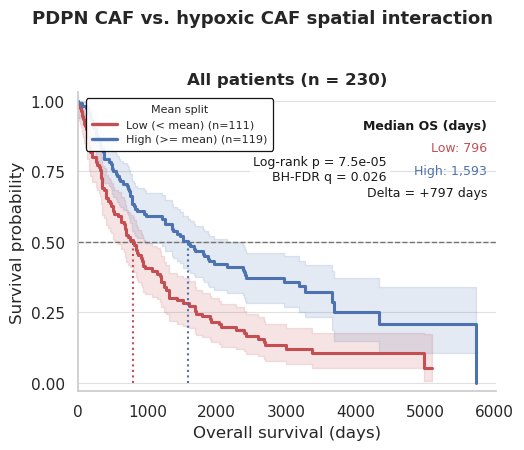

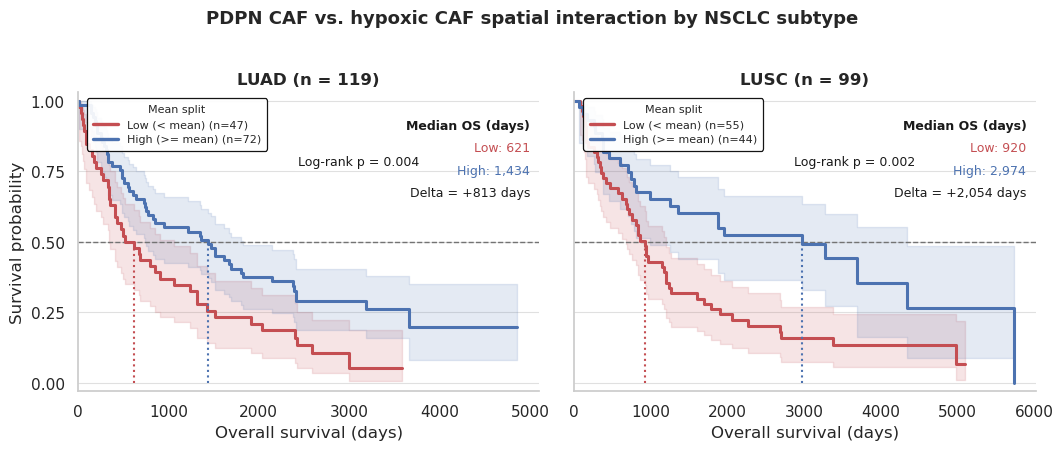

,cohort,tumor_type,feature,n,n_low,n_high,events_low,events_high,mean_cutoff,median_os_low,median_os_high,median_os_delta_high_minus_low,pval_logrank_nominal,pval_adj_bh_all_patient_screen,filter_reason
0,All patients,All,final_cell_type_PDPN CAF_to_final_cell_type_hy...,230,111,119,96.0,78.0,-0.54126,796.0,1593.0,797.0,0.000075,0.025877,tested
1,LUAD,Adenocarcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,119,47,72,41.0,50.0,-0.54126,621.0,1434.0,813.0,0.004257,NaN,tested
2,LUSC,Squamous cell carcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,99,55,44,47.0,25.0,-0.54126,920.0,2974.0,2054.0,0.002160,NaN,tested


In [ ]:
import os

FEATURE_LABELS = {
    "final_cell_type_neutrophils_to_final_cell_type_hypoxic tCAF": "Neutrophils vs. hypoxic tCAF",
}


def clean_feature_label(feature: str) -> str:
    if feature in FEATURE_LABELS:
        return FEATURE_LABELS[feature]
    label = feature.replace("final_cell_type_", "")
    label = label.replace("_to_", " vs. ")
    label = label.replace("_", " ")
    return label


# Source mappings: 00_prepare_clinicaldata.Rmd line 82 sets Gender levels male=1, female=2.
GENDER_LEVEL_LABELS = {"1.0": "male", "2.0": "female"}
# Source mapping: 00_prepare_clinicaldata.Rmd line 100 sets Smok levels no=0, currently=1, former=2, unknown=3.
# The labels below use publication-friendly wording: no -> never smoker, currently -> current smoker, unknown -> smoking unknown.
SMOKING_LEVEL_LABELS = {"0.0": "never smoker", "1.0": "current smoker", "2.0": "former smoker", "3.0": "smoking unknown"}
# Source mappings: 00_prepare_clinicaldata.Rmd lines 94-95 set Chemo/Radio neoadjuvant levels no=0, yes=1.
THERAPY_LEVEL_LABELS = {"0.0": "no", "1.0": "yes"}

COX_VARIABLE_LABELS = {
    "Age": "Age",
    "Stage": "Stage",
    "Grade": "Grade",
}


def clean_dummy_level(raw_level: str, labels: dict) -> str:
    return labels.get(raw_level, raw_level.rstrip(".0"))


def clean_cox_variable_label(variable: str, feature: str) -> str:
    if variable == feature:
        return clean_feature_label(feature)
    if variable in COX_VARIABLE_LABELS:
        return COX_VARIABLE_LABELS[variable]
    if variable.startswith("Gender_"):
        level = variable.split("_", 1)[1]
        label = clean_dummy_level(level, GENDER_LEVEL_LABELS)
        if label == "female":
            return "Female (vs male)"
        return f"{label} (vs reference)"
    if variable.startswith("Smok_"):
        level = variable.split("_", 1)[1]
        label = clean_dummy_level(level, SMOKING_LEVEL_LABELS)
        if label == "current smoker":
            return "Current smoker (vs never)"
        if label == "former smoker":
            return "Former smoker (vs never)"
        if label == "smoking unknown":
            return "Smoking unknown (vs never)"
        return f"{label} (vs reference)"
    if variable.startswith("Chemo_"):
        level = variable.split("_", 1)[1]
        return f"Neoadjuvant chemotherapy: {clean_dummy_level(level, THERAPY_LEVEL_LABELS)} vs no"
    if variable.startswith("Radio_"):
        level = variable.split("_", 1)[1]
        return f"Neoadjuvant radiation: {clean_dummy_level(level, THERAPY_LEVEL_LABELS)} vs no"
    return variable


def format_p_value(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.001:
        return f"{p_value:.1e}"
    return f"{p_value:.3f}"


def format_cox_p_value(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.001:
        return "< 0.001"
    return f"{p_value:.3f}"


def format_days(days):
    if pd.isna(days) or not np.isfinite(days):
        return "not reached"
    return f"{days:,.0f}"


def format_delta_days(delta):
    if pd.isna(delta) or not np.isfinite(delta):
        return "NA"
    return f"{delta:+,.0f} days"


def add_global_mean_groups_for_feature(data: pd.DataFrame, feature: str, method: str):
    grouped_df = data[[feature, "OS", "Ev.O", "Patient_ID", "DX.name"]].dropna(subset=[feature, "OS", "Ev.O"]).copy()
    grouped_df["mean_group"], diagnostics = assign_mean_groups(grouped_df[feature], method)
    return grouped_df, diagnostics


def add_median_os_annotation(ax, medians, colors):
    low_median = medians.get("low", np.nan)
    high_median = medians.get("high", np.nan)
    delta = high_median - low_median if np.isfinite(low_median) and np.isfinite(high_median) else np.nan

    x = 0.98
    y = 0.91
    line_height = 0.075
    ax.text(x, y, "Median OS (days)", transform=ax.transAxes, ha="right", va="top", fontsize=9, fontweight="bold", color="0.10", zorder=5)
    ax.text(x, y - line_height, f"Low: {format_days(low_median)}", transform=ax.transAxes, ha="right", va="top", fontsize=9, color=colors["low"], zorder=5)
    ax.text(x, y - 2 * line_height, f"High: {format_days(high_median)}", transform=ax.transAxes, ha="right", va="top", fontsize=9, color=colors["high"], zorder=5)
    ax.text(x, y - 3 * line_height, f"Delta = {format_delta_days(delta)}", transform=ax.transAxes, ha="right", va="top", fontsize=9, color="0.10", zorder=5)
    return delta


def add_logrank_annotation(ax, p_lines):
    ax.text(
        0.74,
        0.79,
        "\n".join(p_lines),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="0.10",
        bbox={"boxstyle": "square,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.82},
        zorder=5,
    )


def add_median_guides(ax, medians, colors):
    ax.axhline(0.5, color="0.45", linestyle="--", linewidth=1.0, zorder=1)
    for group, median_survival in medians.items():
        if pd.notna(median_survival) and np.isfinite(median_survival):
            ax.vlines(
                median_survival,
                ymin=0,
                ymax=0.5,
                color=colors[group],
                linestyle=":",
                linewidth=1.5,
                zorder=2,
            )


def style_group_legend(legend):
    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("black")
    frame.set_linewidth(0.9)
    frame.set_alpha(0.92)
    for line in legend.get_lines():
        line.set_linewidth(2.4)


def plot_km_mean_split(ax, grouped_df, diagnostics, feature, title, tumor_type=None, q_value=None):
    km_df = grouped_df.copy()
    if tumor_type is not None:
        km_df = km_df.loc[km_df["DX.name"] == tumor_type].copy()

    if km_df.empty:
        ax.set_title(f"{title}\nno patients", fontsize=11, fontweight="bold")
        ax.axis("off")
        return {"cohort": title, "tumor_type": tumor_type or "All", "feature": feature, "n": 0, "filter_reason": "no_patients"}

    group_order = GROUP_ORDER
    counts = km_df["mean_group"].value_counts().reindex(group_order, fill_value=0)
    events = km_df.groupby("mean_group")["Ev.O"].sum().reindex(group_order, fill_value=0)
    nonempty_groups = counts[counts > 0].index.tolist()

    deep = sns.color_palette("deep", 10)
    colors = {"low": deep[3], "high": deep[0]}
    labels = {"low": "Low (< mean)", "high": "High (>= mean)"}

    kmf = KaplanMeierFitter()
    medians = {group: np.nan for group in group_order}
    for group in group_order:
        group_df = km_df.loc[km_df["mean_group"] == group]
        if group_df.empty:
            continue
        kmf.fit(group_df["OS"], event_observed=group_df["Ev.O"], label=f"{labels[group]} (n={group_df.shape[0]})")
        kmf.plot(ax=ax, c=colors[group], linewidth=2.2, ci_show=True, ci_alpha=0.15)
        medians[group] = kmf.median_survival_time_

    add_median_guides(ax, medians, colors)
    median_delta = add_median_os_annotation(ax, medians, colors)

    p_value = np.nan
    filter_reason = "tested"
    if len(nonempty_groups) == 2:
        try:
            res = run_two_group_logrank(km_df)
            p_value = res.p_value
        except Exception as exc:
            filter_reason = f"logrank_error: {exc}"
    else:
        filter_reason = "single_nonempty_group"

    p_lines = [f"Log-rank p = {format_p_value(p_value)}"]
    if q_value is not None and pd.notna(q_value):
        p_lines.append(f"BH-FDR q = {format_p_value(q_value)}")

    panel_title = f"{title} (n = {km_df.shape[0]})"
    ax.set_title(panel_title, fontsize=12, fontweight="bold")
    add_logrank_annotation(ax, p_lines)
    ax.set_xlabel("Overall survival (days)")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlim(left=0)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.grid(axis="y", color="0.88", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    legend = ax.legend(
        title="Mean split",
        frameon=True,
        fontsize=8,
        title_fontsize=8,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        borderaxespad=0,
        borderpad=0.55,
        labelspacing=0.45,
        handlelength=2.2,
    )
    style_group_legend(legend)
    return {
        "cohort": title, "tumor_type": tumor_type or "All", "feature": feature,
        "n": km_df.shape[0], "n_low": counts["low"], "n_high": counts["high"],
        "events_low": events["low"], "events_high": events["high"],
        **diagnostics,
        "median_os_low": medians["low"],
        "median_os_high": medians["high"],
        "median_os_delta_high_minus_low": median_delta,
        "pval_logrank_nominal": p_value,
        "pval_adj_bh_all_patient_screen": q_value,
        "filter_reason": filter_reason,
    }


km_results = []
if mean_results_df.empty:
    print("No features passed the mean-split survival screen.")
else:
    method = "mean_cutoff"
    method_screen = mean_results_df.loc[mean_results_df["method"] == method].sort_values("pval_logrank")
    top_feature_row = method_screen.iloc[0]
    best_feature = top_feature_row["feature"]
    best_feature_q = top_feature_row.get("pval_adj_bh", np.nan)
    feature_title = clean_feature_label(best_feature)
    grouped_feature_df, grouped_feature_diagnostics = add_global_mean_groups_for_feature(
        spatial_clinical_for_survival,
        best_feature,
        method,
    )
    print(f"Top feature: {feature_title} ({best_feature})")
    print("All patients report the all-feature BH-FDR q-value; LUAD/LUSC p-values are nominal subgroup log-rank tests.")

    fig, ax = plt.subplots(figsize=(5.4, 4.4))
    km_results.append(plot_km_mean_split(
        ax,
        grouped_feature_df,
        grouped_feature_diagnostics,
        best_feature,
        "All patients",
        tumor_type=None,
        q_value=best_feature_q,
    ))
    fig.suptitle(f"{feature_title} spatial interaction", fontsize=13, fontweight="bold", y=1.02)
    
    plt.tight_layout()
    res_base_dir = '/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/05-20-26_results'
    plt.savefig(os.path.join(res_base_dir, 'pdpn_hypoxic_caf_all.pdf'), bbox_inches="tight")
    plt.show()

    subtype_cohorts = [("LUAD", "Adenocarcinoma"), ("LUSC", "Squamous cell carcinoma")]
    fig, axes = plt.subplots(1, len(subtype_cohorts), figsize=(10.8, 4.4), sharey=True)
    for ax, (title, tumor_type) in zip(axes, subtype_cohorts):
        km_results.append(plot_km_mean_split(
            ax,
            grouped_feature_df,
            grouped_feature_diagnostics,
            best_feature,
            title,
            tumor_type=tumor_type,
            q_value=None,
        ))
    fig.suptitle(f"{feature_title} spatial interaction by NSCLC subtype", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    # plt.savefig(os.path.join(res_base_dir, 'pdpn_hypoxic_caf_subtype.pdf'), bbox_inches="tight")

    plt.show()

km_results_df = pd.DataFrame(km_results)
display(km_results_df)

In [8]:
grouped_feature_df

,final_cell_type_PDPN CAF_to_final_cell_type_hypoxic CAF,OS,Ev.O,Patient_ID,DX.name,mean_group
0,-1.241516,254.0,1.0,175_1,Adenocarcinoma,low
5,0.458985,605.0,1.0,175_103,Adenocarcinoma,high
6,-0.379374,371.0,1.0,175_104,Squamous cell carcinoma,high
13,-1.457103,676.0,1.0,175_111,Squamous cell carcinoma,low
14,-0.577201,1693.0,1.0,175_112,Large cell carcinoma,low
...,...,...,...,...,...,...
938,0.130630,596.0,1.0,88_521,Squamous cell carcinoma,high
940,-1.260641,405.0,1.0,88_524,Adenocarcinoma,low
941,0.002763,323.0,1.0,88_525,Adenocarcinoma,high
947,-0.115698,1671.0,0.0,88_531,Adenocarcinoma,high


Subtype-specific mean cutoffs


,cohort,tumor_type,feature,n,n_low,n_high,events_low,events_high,mean_cutoff
0,LUAD,Adenocarcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,119,53,66,45.0,46.0,-0.442562
1,LUSC,Squamous cell carcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,99,48,51,43.0,29.0,-0.631540


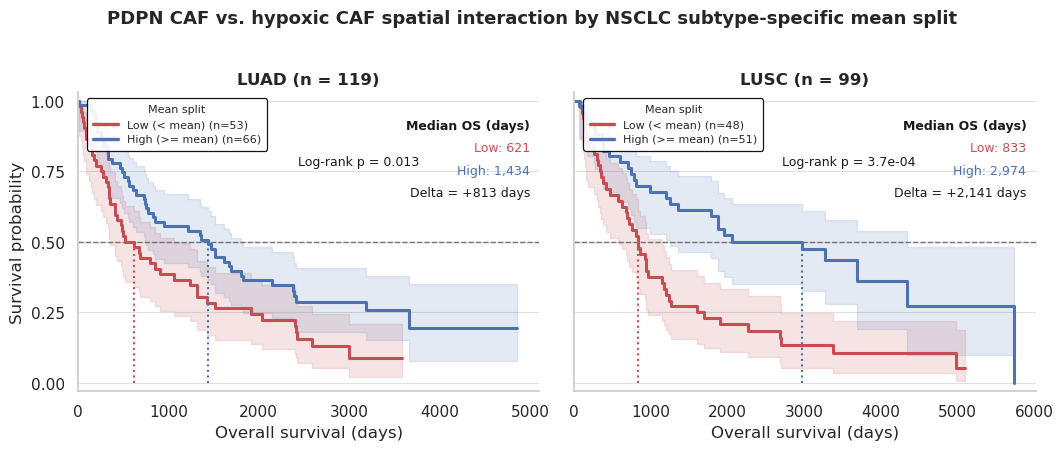

,cohort,tumor_type,feature,n,n_low,n_high,events_low,events_high,mean_cutoff,median_os_low,median_os_high,median_os_delta_high_minus_low,pval_logrank_nominal,pval_adj_bh_all_patient_screen,filter_reason
0,LUAD,Adenocarcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,119,53,66,45.0,46.0,-0.442562,621.0,1434.0,813.0,0.013270,None,tested
1,LUSC,Squamous cell carcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,99,48,51,43.0,29.0,-0.631540,833.0,2974.0,2141.0,0.000366,None,tested


In [ ]:
# by NSCLC subtype-specific mean split
subtype_specific_km_results = []
subtype_specific_cutoff_rows = []
subtype_specific_grouped_feature = {}


def add_subtype_mean_groups_for_feature(data: pd.DataFrame, feature: str, method: str, tumor_type: str):
    subtype_df = data.loc[
        data["DX.name"] == tumor_type,
        [feature, "OS", "Ev.O", "Patient_ID", "DX.name"],
    ].dropna(subset=[feature, "OS", "Ev.O"]).copy()
    subtype_df["mean_group"], diagnostics = assign_mean_groups(subtype_df[feature], method)
    return subtype_df, diagnostics


if mean_results_df.empty:
    print("No features passed the mean-split survival screen.")
else:
    method = "mean_cutoff"
    subtype_cohorts = [("LUAD", "Adenocarcinoma"), ("LUSC", "Squamous cell carcinoma")]

    if "best_feature" not in globals():
        method_screen = mean_results_df.loc[mean_results_df["method"] == method].sort_values("pval_logrank")
        best_feature = method_screen.iloc[0]["feature"]
    feature_title = clean_feature_label(best_feature)

    for title, tumor_type in subtype_cohorts:
        subtype_grouped_df, subtype_diagnostics = add_subtype_mean_groups_for_feature(
            spatial_clinical_for_survival,
            best_feature,
            method,
            tumor_type,
        )
        subtype_specific_grouped_feature[title] = {
            "grouped_df": subtype_grouped_df,
            "diagnostics": subtype_diagnostics,
            "tumor_type": tumor_type,
        }

        counts = subtype_grouped_df["mean_group"].value_counts().reindex(GROUP_ORDER, fill_value=0)
        events = subtype_grouped_df.groupby("mean_group")["Ev.O"].sum().reindex(GROUP_ORDER, fill_value=0)
        subtype_specific_cutoff_rows.append({
            "cohort": title,
            "tumor_type": tumor_type,
            "feature": best_feature,
            "n": subtype_grouped_df.shape[0],
            "n_low": counts["low"],
            "n_high": counts["high"],
            "events_low": events["low"],
            "events_high": events["high"],
            **subtype_diagnostics,
        })

    subtype_specific_cutoffs_df = pd.DataFrame(subtype_specific_cutoff_rows)
    print("Subtype-specific mean cutoffs")
    display(subtype_specific_cutoffs_df)

    fig, axes = plt.subplots(1, len(subtype_cohorts), figsize=(10.8, 4.4), sharey=True)
    for ax, (title, tumor_type) in zip(axes, subtype_cohorts):
        subtype_info = subtype_specific_grouped_feature[title]
        subtype_specific_km_results.append(plot_km_mean_split(
            ax,
            subtype_info["grouped_df"],
            subtype_info["diagnostics"],
            best_feature,
            title,
            tumor_type=tumor_type,
            q_value=None,
        ))
    fig.suptitle(f"{feature_title} spatial interaction by NSCLC subtype-specific mean split", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    subtype_specific_km_results_df = pd.DataFrame(subtype_specific_km_results)
    display(subtype_specific_km_results_df)

## Adjusted Multivariable Cox PH Model

The mean split above is only used to screen candidate interaction variables. The Cox model uses the raw continuous spatial interaction index for the top screened feature and adjusts for Age, Stage, Grade, Gender, and Smoking. Stage and Grade are treated as continuous numeric covariates. Chemo and radiation are included only when they have enough non-missing contrast in the selected feature subset.

In [10]:
def load_patient_clinical_covariates():
    clinical_covariates = ["Age", "Gender", "Stage", "Grade", "Smok", "Chemo", "Radio"]
    cox_clinical_data = pd.read_csv(CLINICAL_PATH)
    cox_clinical_data = cox_clinical_data.loc[cox_clinical_data["Patient_ID"] != "Control"].copy()
    cox_clinical_data = cox_clinical_data.loc[~cox_clinical_data["NeoAdj"].isna()].copy()
    cox_clinical_data = cox_clinical_data.loc[cox_clinical_data["NeoAdj"] != "NeoAdjuvantTherapy"].reset_index(drop=True)
    cox_clinical_data = cox_clinical_data[["Patient_ID"] + clinical_covariates].drop_duplicates()

    clinical_conflicts = cox_clinical_data.groupby("Patient_ID")[clinical_covariates].nunique(dropna=False)
    clinical_conflicts = clinical_conflicts[(clinical_conflicts > 1).any(axis=1)]
    print(f"Patients with ROI-level clinical covariate conflicts: {len(clinical_conflicts)}")

    cox_clinical_data = cox_clinical_data.drop_duplicates(subset="Patient_ID", keep="first").reset_index(drop=True)
    for col in clinical_covariates:
        cox_clinical_data[col] = pd.to_numeric(cox_clinical_data[col], errors="coerce")
    return cox_clinical_data


def select_default_cox_feature(screen_df: pd.DataFrame):
    if screen_df.empty:
        raise RuntimeError("No screened features are available for Cox modeling.")
    top_row = screen_df.sort_values("pval_logrank").iloc[0]
    return str(top_row["feature"]), str(top_row["method"]), float(top_row["pval_logrank"])


def order_cox_rows(df: pd.DataFrame, feature: str) -> pd.DataFrame:
    ordered = df.copy()
    ordered["_coef_sort"] = pd.to_numeric(ordered["coef"], errors="coerce")
    ordered["_positive_coef_sort"] = ordered["_coef_sort"] > 0
    ordered = ordered.sort_values(
        ["_positive_coef_sort", "_coef_sort", "variable"],
        ascending=[False, False, True],
    ).drop(columns=["_positive_coef_sort", "_coef_sort"]).reset_index(drop=True)
    return ordered


def run_adjusted_continuous_cox(data: pd.DataFrame, clinical_df: pd.DataFrame, feature: str):
    cox_df = data[["Patient_ID", "OS", "Ev.O", feature]].merge(clinical_df, how="left", on="Patient_ID")
    clinical_covariates = ["Age", "Gender", "Stage", "Grade", "Smok", "Chemo", "Radio"]
    print(f"Patients before dropping missing values: {cox_df['Patient_ID'].nunique()}")
    print("Missing values before Cox model:")
    display(cox_df[["OS", "Ev.O", feature] + clinical_covariates].isna().sum().to_frame("n_missing"))

    base_covariates = [feature, "Age", "Stage", "Grade", "Gender", "Smok"]
    optional_covariates = []
    therapy_decisions = []
    feature_nonmissing = cox_df[feature].notna()
    for therapy_col in ["Chemo", "Radio"]:
        therapy_counts = cox_df.loc[feature_nonmissing, therapy_col].value_counts(dropna=True)
        missing_frac = cox_df.loc[feature_nonmissing, therapy_col].isna().mean()
        include_therapy = missing_frac <= 0.30 and len(therapy_counts) >= 2 and therapy_counts.min() >= 10
        if include_therapy:
            optional_covariates.append(therapy_col)
        therapy_decisions.append(f"{therapy_col}: include={include_therapy}, missing={missing_frac:.1%}, counts={therapy_counts.to_dict()}")

    print("Therapy covariate decisions:")
    for decision in therapy_decisions:
        print(decision)

    cox_covariates = base_covariates + optional_covariates
    cox_model_df = cox_df[["OS", "Ev.O"] + cox_covariates].dropna().copy()

    categorical_covariates = ["Gender", "Smok"] + optional_covariates
    for col in categorical_covariates:
        cox_model_df[col] = cox_model_df[col].astype("category")

    cox_model_df = pd.get_dummies(cox_model_df, columns=categorical_covariates, drop_first=True, dtype=float)
    covariate_cols = [col for col in cox_model_df.columns if col not in ["OS", "Ev.O"]]
    nonconstant_cols = [col for col in covariate_cols if cox_model_df[col].nunique(dropna=True) > 1]
    cox_model_df = cox_model_df[["OS", "Ev.O"] + nonconstant_cols]

    print(f"Patients in Cox model after complete-case filtering: {cox_model_df.shape[0]}")
    print(f"Events in Cox model: {int(cox_model_df['Ev.O'].sum())}")

    cph = CoxPHFitter()
    cph.fit(cox_model_df, duration_col="OS", event_col="Ev.O")

    summary = cph.summary.reset_index().rename(columns={"covariate": "variable"})
    summary = summary[["variable", "coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
    summary.insert(0, "feature", feature)
    summary.insert(1, "n_model", cox_model_df.shape[0])
    summary.insert(2, "events_model", int(cox_model_df["Ev.O"].sum()))
    summary["therapy_decisions"] = "; ".join(therapy_decisions)
    summary = order_cox_rows(summary, feature)
    return summary, cph

In [11]:
patient_covariates = load_patient_clinical_covariates()

cox_feature, cox_feature_source_method, cox_feature_screen_pval = select_default_cox_feature(mean_results_df)
print(f"Default Cox feature from top mean-split screen: {cox_feature}")
print(f"Source method: {cox_feature_source_method}; two-sample log-rank p = {cox_feature_screen_pval:.3g}")

cox_summary_df, cph = run_adjusted_continuous_cox(spatial_clinical_for_survival, patient_covariates, cox_feature)

Patients with ROI-level clinical covariate conflicts: 0
Default Cox feature from top mean-split screen: final_cell_type_PDPN CAF_to_final_cell_type_hypoxic CAF
Source method: mean_cutoff; two-sample log-rank p = 7.46e-05
Patients before dropping missing values: 953
Missing values before Cox model:


,n_missing
OS,0
Ev.O,0
final_cell_type_PDPN CAF_to_final_cell_type_hypoxic CAF,723
Age,10
Gender,10
Stage,10
Grade,10
Smok,0
Chemo,0
Radio,0


Therapy covariate decisions:
Chemo: include=False, missing=0.0%, counts={0.0: 230}
Radio: include=False, missing=0.0%, counts={0.0: 230}
Patients in Cox model after complete-case filtering: 228
Events in Cox model: 174


## Forest Plot For Continuous Cox Model

The Cox analysis keeps the existing model specification: age, stage, grade, and the spatial interaction index are continuous; gender and smoking are dummy-encoded using the clinical labels from `00_prepare_clinicaldata.Rmd`. Point color indicates positive versus negative Cox coefficient direction, and black-edged points mark nominal Cox p < 0.05; the formatted HR and p-value table is printed in the following code cell.


Saved /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nsclc_spatial_mean_split_continuous_cox_forest.pdf


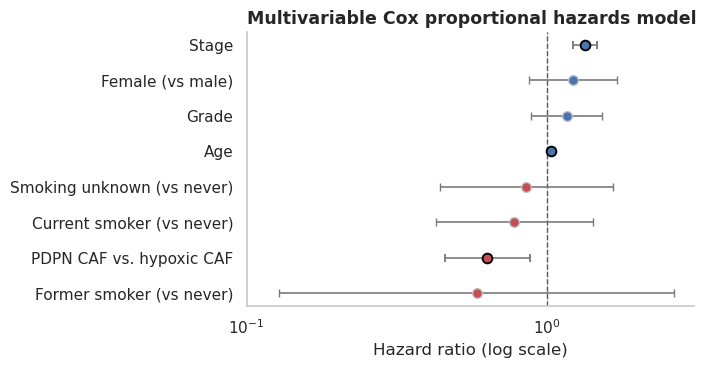

Saved /project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nsclc_spatial_mean_split_continuous_cox_forest_legend.pdf


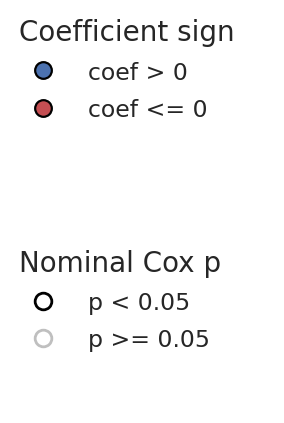

In [12]:
from matplotlib.lines import Line2D
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter

FOREST_PLOT_PDF_PATH = WORK_DIR / "nsclc_spatial_mean_split_continuous_cox_forest.pdf"
FOREST_LEGEND_PDF_PATH = WORK_DIR / "nsclc_spatial_mean_split_continuous_cox_forest_legend.pdf"


def add_log_scale_decade_ticks(ax, lower_ci_min):
    if pd.notna(lower_ci_min) and np.isfinite(lower_ci_min) and lower_ci_min < 0.2:
        ax.set_xlim(left=10 ** np.floor(np.log10(lower_ci_min)))
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())


def plot_forest_legend(direction_colors, output_path):
    legend_fig, legend_ax = plt.subplots(figsize=(3.0, 4.4))
    legend_ax.axis("off")

    sign_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=direction_colors[True], markeredgecolor="black", markeredgewidth=1.6, markersize=12, label="coef > 0"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=direction_colors[False], markeredgecolor="black", markeredgewidth=1.6, markersize=12, label="coef <= 0"),
    ]
    sign_legend = legend_ax.legend(
        handles=sign_handles,
        title="Coefficient sign",
        frameon=False,
        fontsize=17,
        title_fontsize=20,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.0),
        borderaxespad=0,
        handletextpad=0.9,
        labelspacing=0.6,
    )
    sign_legend._legend_box.align = "left"
    legend_ax.add_artist(sign_legend)

    p_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black", markeredgewidth=2.0, markersize=12, label="p < 0.05"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="0.75", markeredgewidth=2.0, markersize=12, label="p >= 0.05"),
    ]
    p_legend = legend_ax.legend(
        handles=p_handles,
        title="Nominal Cox p",
        frameon=False,
        fontsize=17,
        title_fontsize=20,
        loc="upper left",
        bbox_to_anchor=(0.0, 0.43),
        borderaxespad=0,
        handletextpad=0.9,
        labelspacing=0.6,
    )
    p_legend._legend_box.align = "left"

    plt.tight_layout()
    legend_fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    plt.show()


if cox_summary_df.empty:
    print("No Cox summary available for forest plot.")
else:
    plot_df = cox_summary_df.copy()
    plot_df["label"] = plot_df["variable"].map(lambda variable: clean_cox_variable_label(variable, cox_feature))
    plot_df["positive_coef"] = plot_df["coef"] > 0
    plot_df["nominal_cox_p_significant"] = plot_df["p"] < 0.05
    plot_df = order_cox_rows(plot_df, cox_feature)
    y_pos = np.arange(plot_df.shape[0])

    deep = sns.color_palette("deep", 10)
    direction_colors = {True: deep[0], False: deep[3]}

    fig, ax = plt.subplots(figsize=(7.2, max(3.2, 0.48 * plot_df.shape[0])))

    for y, (_, row) in zip(y_pos, plot_df.iterrows()):
        hr = row["exp(coef)"]
        lower = row["exp(coef) lower 95%"]
        upper = row["exp(coef) upper 95%"]
        significant = bool(pd.notna(row["p"]) and row["p"] < 0.05)
        point_color = direction_colors[row["positive_coef"]]
        ax.errorbar(
            hr,
            y,
            xerr=[[hr - lower], [upper - hr]],
            fmt="o",
            markersize=7,
            markerfacecolor=point_color,
            markeredgecolor="black" if significant else "0.75",
            markeredgewidth=1.35 if significant else 1.0,
            alpha=1.0,
            ecolor="0.48",
            elinewidth=1.2,
            capsize=3,
            zorder=3,
        )

    ax.axvline(1, color="0.35", linestyle="--", linewidth=1.0, zorder=1)
    ax.set_xscale("log")
    add_log_scale_decade_ticks(ax, plot_df["exp(coef) lower 95%"].min())
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df["label"])
    ax.invert_yaxis()
    ax.set_xlabel("Hazard ratio (log scale)")
    ax.set_title("Multivariable Cox proportional hazards model", fontsize=12.5, fontweight="bold", loc="left")
    ax.grid(axis="x", which="major", color="0.88", linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(FOREST_PLOT_PDF_PATH, bbox_inches="tight")
    print(f"Saved {FOREST_PLOT_PDF_PATH}")
    plt.show()

    plot_forest_legend(direction_colors, FOREST_LEGEND_PDF_PATH)

In [13]:
cox_summary_df

,feature,n_model,events_model,variable,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p,therapy_decisions
0,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,Stage,0.289858,1.336238,1.217702,1.466313,9.607227e-10,"Chemo: include=False, missing=0.0%, counts={0...."
1,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,Gender_2.0,0.197744,1.218650,0.868507,1.709956,2.525360e-01,"Chemo: include=False, missing=0.0%, counts={0...."
2,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,Grade,0.150821,1.162788,0.886692,1.524855,2.755052e-01,"Chemo: include=False, missing=0.0%, counts={0...."
3,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,Age,0.028691,1.029107,1.011582,1.046935,1.060303e-03,"Chemo: include=False, missing=0.0%, counts={0...."
4,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,Smok_3.0,-0.159120,0.852894,0.440376,1.651833,6.370618e-01,"Chemo: include=False, missing=0.0%, counts={0...."
5,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,Smok_1.0,-0.253025,0.776449,0.425241,1.417720,4.101191e-01,"Chemo: include=False, missing=0.0%, counts={0...."
6,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,final_cell_type_PDPN CAF_to_final_cell_type_hy...,-0.457586,0.632810,0.457237,0.875799,5.783258e-03,"Chemo: include=False, missing=0.0%, counts={0...."
7,final_cell_type_PDPN CAF_to_final_cell_type_hy...,228,174,Smok_2.0,-0.540208,0.582627,0.128198,2.647900,4.843376e-01,"Chemo: include=False, missing=0.0%, counts={0...."


In [14]:
if cox_summary_df.empty:
    print("No Cox summary available for formatted HR table.")
else:
    cox_table_df = cox_summary_df.copy()
    cox_table_df["Covariate"] = cox_table_df["variable"].map(lambda variable: clean_cox_variable_label(variable, cox_feature))
    cox_table_df["HR (95% CI)"] = cox_table_df.apply(
        lambda row: f"{row['exp(coef)']:.2f} ({row['exp(coef) lower 95%']:.2f}-{row['exp(coef) upper 95%']:.2f})",
        axis=1,
    )
    cox_table_df["p value"] = cox_table_df["p"].map(format_cox_p_value)
    cox_table_df = order_cox_rows(cox_table_df, cox_feature)
    display(cox_table_df[["Covariate", "HR (95% CI)", "p value"]])


,Covariate,HR (95% CI),p value
0,Stage,1.34 (1.22-1.47),< 0.001
1,Female (vs male),1.22 (0.87-1.71),0.253
2,Grade,1.16 (0.89-1.52),0.276
3,Age,1.03 (1.01-1.05),0.001
4,Smoking unknown (vs never),0.85 (0.44-1.65),0.637
5,Current smoker (vs never),0.78 (0.43-1.42),0.410
6,PDPN CAF vs. hypoxic CAF,0.63 (0.46-0.88),0.006
7,Former smoker (vs never),0.58 (0.13-2.65),0.484
